In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = "/content/drive/MyDrive/african-wildlife.zip"  # update if needed

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/")

print("Train:", len(os.listdir("/content/african-wildlife/images/train")))
print("Val:  ", len(os.listdir("/content/african-wildlife/images/val")))
print("Test: ", len(os.listdir("/content/african-wildlife/images/test")))

Mounted at /content/drive
Train: 1052
Val:   225
Test:  227


In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.6 MB/s eta 0:00:00


In [3]:
import os, yaml, torch, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# CONFIG
# ─────────────────────────────────────────
DATASET_PATH = "/content/african-wildlife"
YAML_PATH    = "/content/african-wildlife/african-wildlife.yaml"
EPOCHS       = 10
IMG_SIZE     = 416
BATCH        = 32
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")


Using device: cuda


In [5]:
# FIX YAML
# ─────────────────────────────────────────
with open(YAML_PATH, "w") as f:
    yaml.dump({
        "path":  DATASET_PATH,
        "train": "images/train",
        "val":   "images/val",
        "test":  "images/test",
        "names": {
            0: "buffalo",
            1: "elephant",
            2: "rhino",
            3: "zebra"
        }
    }, f, default_flow_style=False)
print("✅ YAML ready")

✅ YAML ready


In [6]:
# TRAIN YOLOv8 (pretrained)
# ─────────────────────────────────────────
model_v8 = YOLO("yolov8n.pt")

model_v8.train(
    data     = YAML_PATH,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    device   = DEVICE,
    name     = "v8",
    project  = "results",
    exist_ok = True,
    freeze   = 10,
    optimizer= "Adam",
    lr0      = 0.001,
    verbose  = False
)
print("✅ YOLOv8 done!")

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/african-wildlife/african-wildlife.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=100, p

In [7]:
# TRAIN YOLOv5 (pretrained)
# ─────────────────────────────────────────
model_v5 = YOLO("yolov5nu.pt")

model_v5.train(
    data     = YAML_PATH,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    device   = DEVICE,
    name     = "v5",
    project  = "results",
    exist_ok = True,
    freeze   = 10,
    optimizer= "Adam",
    lr0      = 0.001,
    verbose  = False
)
print("✅ YOLOv5 done!")

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/african-wildlife/african-wildlife.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v5, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=100, 

In [10]:
# LOAD BEST WEIGHTS
# ─────────────────────────────────────────
# Auto-find weights
def find_weights(project, name):
    matches = sorted(Path(project).rglob("best.pt"))
    for m in matches:
        if name in str(m):
            print(f"✅ Found: {m}")
            return str(m)
    # fallback: return first match
    if matches:
        print(f"⚠️ Using fallback: {matches[0]}")
        return str(matches[0])
    return None

v8_path = find_weights("results", "v8")
v5_path = find_weights("results", "v5")

best_v8 = YOLO("/content/runs/detect/results/v8/weights/best.pt")
best_v5 = YOLO("/content/runs/detect/results/v5/weights/best.pt")

In [11]:
# ENSEMBLE FUNCTION
# ─────────────────────────────────────────
def compute_iou(box, boxes):
    x1 = np.maximum(box[0], boxes[:, 0])
    y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2])
    y2 = np.minimum(box[3], boxes[:, 3])
    inter = np.maximum(0, x2-x1) * np.maximum(0, y2-y1)
    area1 = (box[2]-box[0]) * (box[3]-box[1])
    area2 = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    return inter / (area1 + area2 - inter + 1e-6)

def ensemble_predict(img_path, m1, m2, conf=0.25, iou_thresh=0.5):
    r1 = m1.predict(img_path, conf=conf, verbose=False)[0]
    r2 = m2.predict(img_path, conf=conf, verbose=False)[0]

    all_boxes, all_conf, all_cls = [], [], []
    for r in [r1, r2]:
        if r.boxes and len(r.boxes):
            all_boxes.append(r.boxes.xyxy.cpu().numpy())
            all_conf.append(r.boxes.conf.cpu().numpy())
            all_cls.append(r.boxes.cls.cpu().numpy())

    if not all_boxes:
        return np.array([]), np.array([]), np.array([])

    boxes   = np.vstack(all_boxes)
    confs   = np.concatenate(all_conf)
    classes = np.concatenate(all_cls)

    order = np.argsort(confs)[::-1]
    boxes, confs, classes = boxes[order], confs[order], classes[order]
    keep = []
    suppressed = np.zeros(len(boxes), dtype=bool)
    for i in range(len(boxes)):
        if not suppressed[i]:
            keep.append(i)
            if i+1 < len(boxes):
                ious = compute_iou(boxes[i], boxes[i+1:])
                suppressed[i+1:] |= ious > iou_thresh

    idx = np.array(keep)
    return boxes[idx], confs[idx], classes[idx]

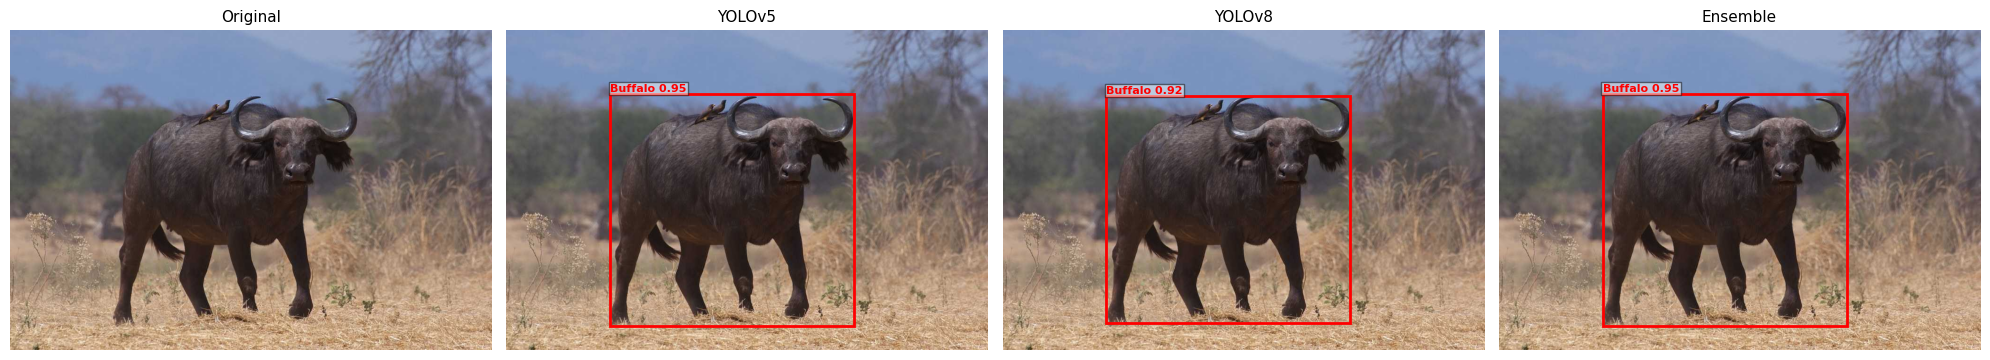

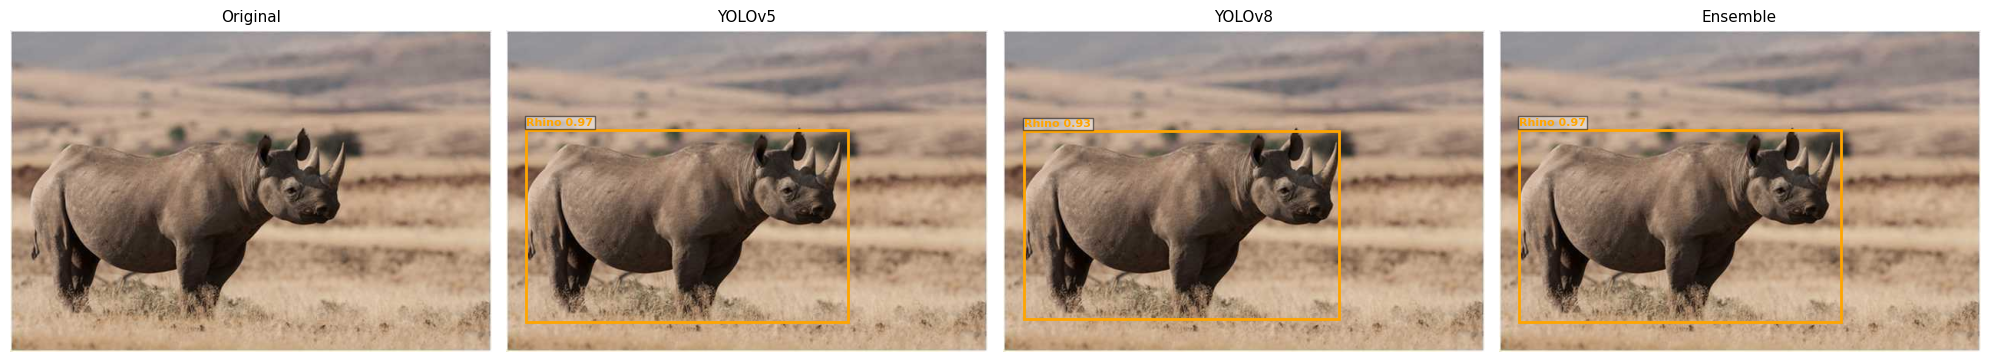

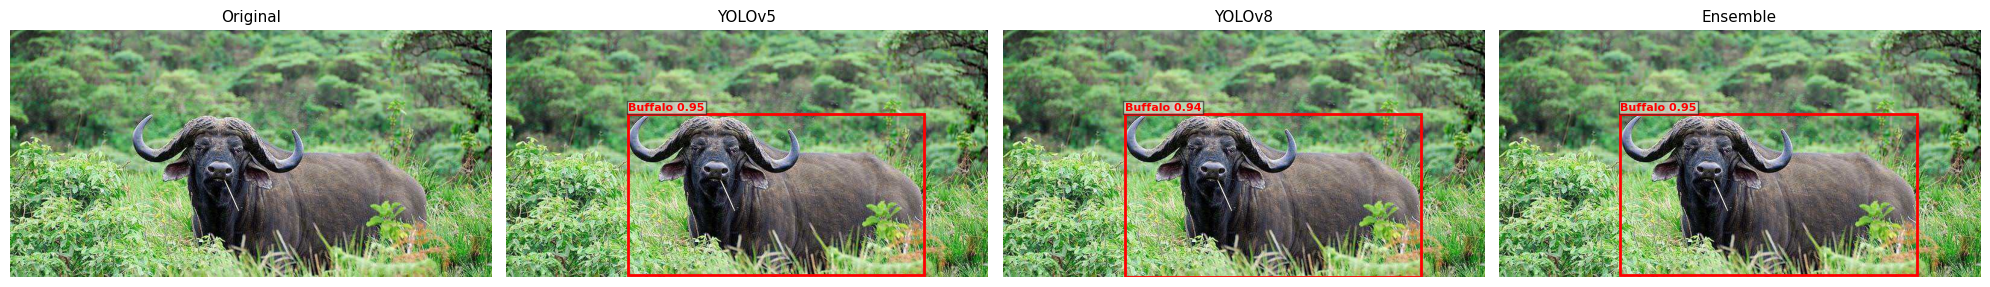

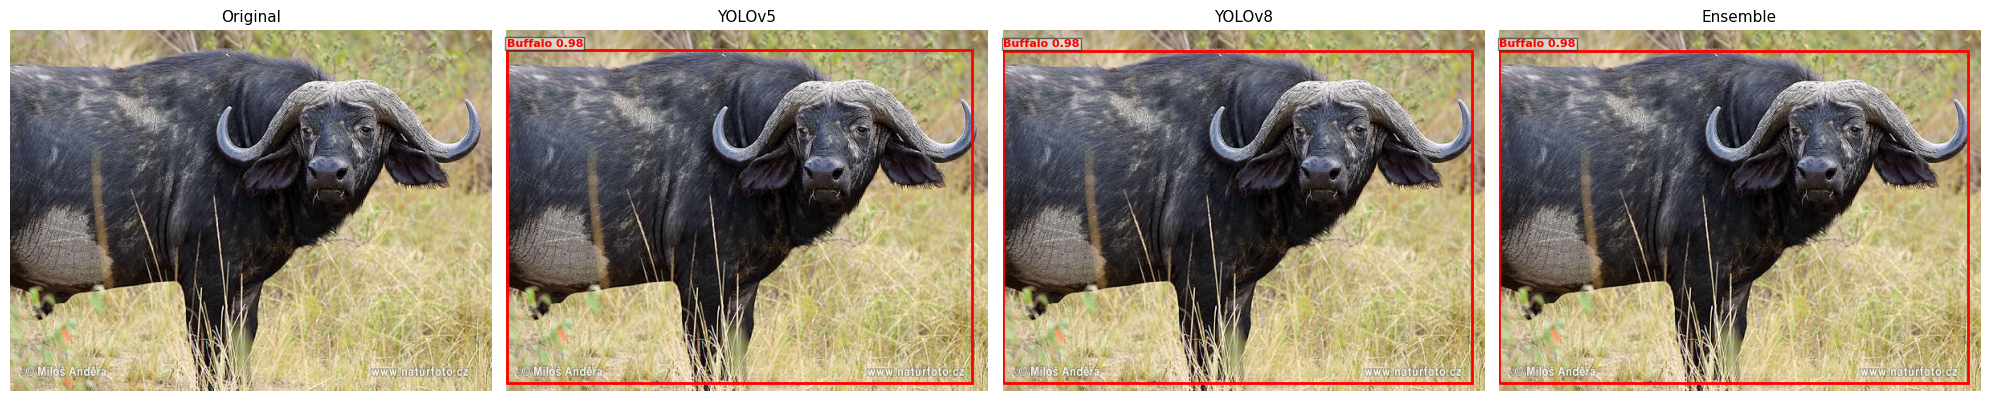

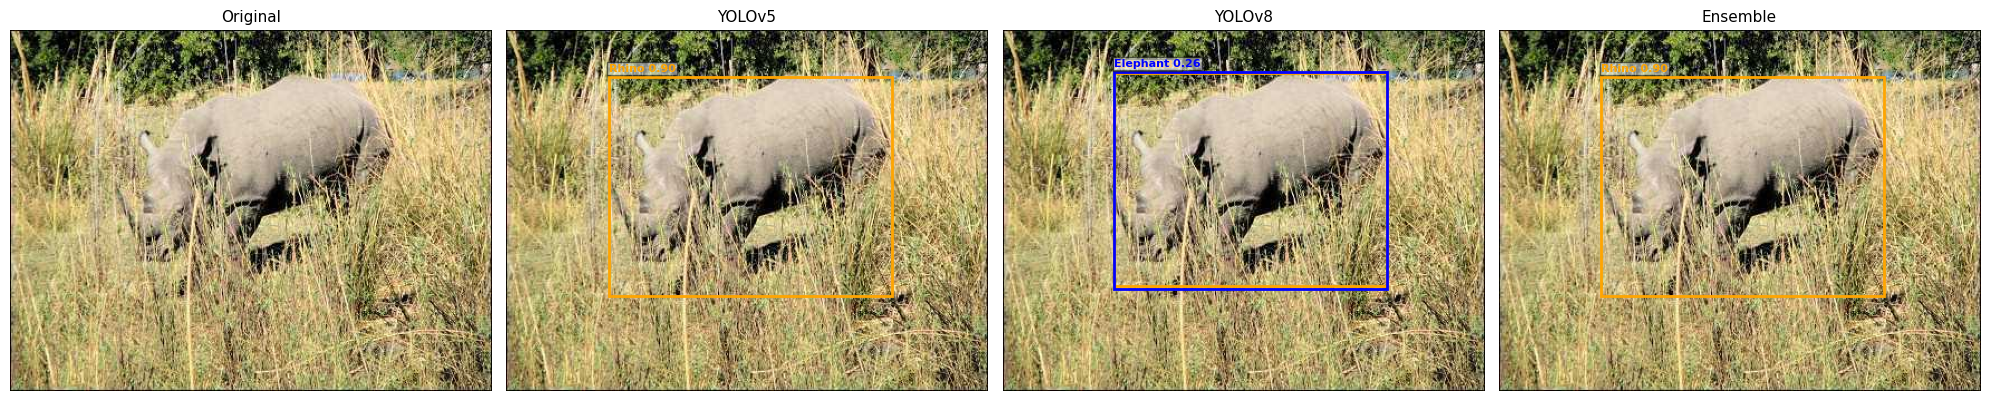


--- TEST IMAGES ---


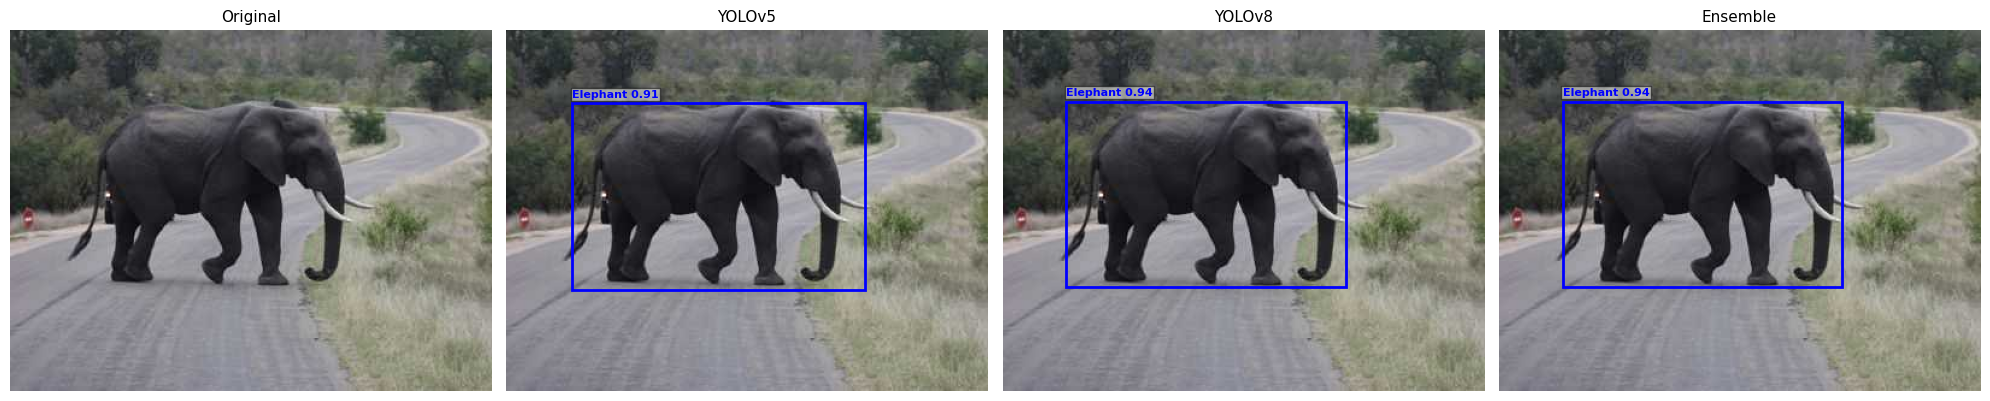

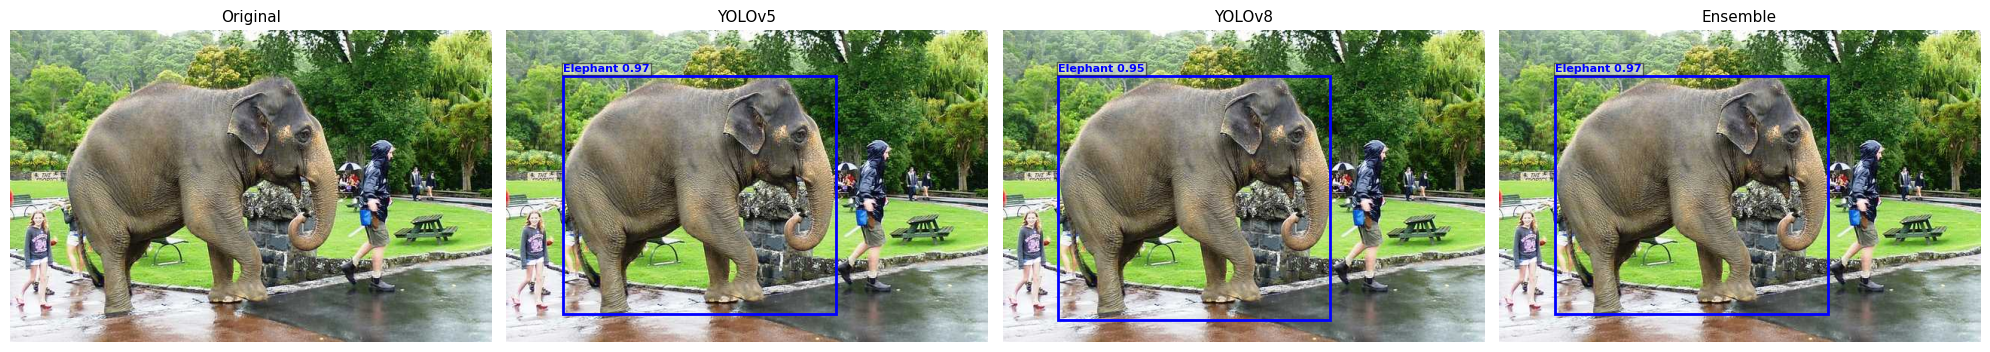

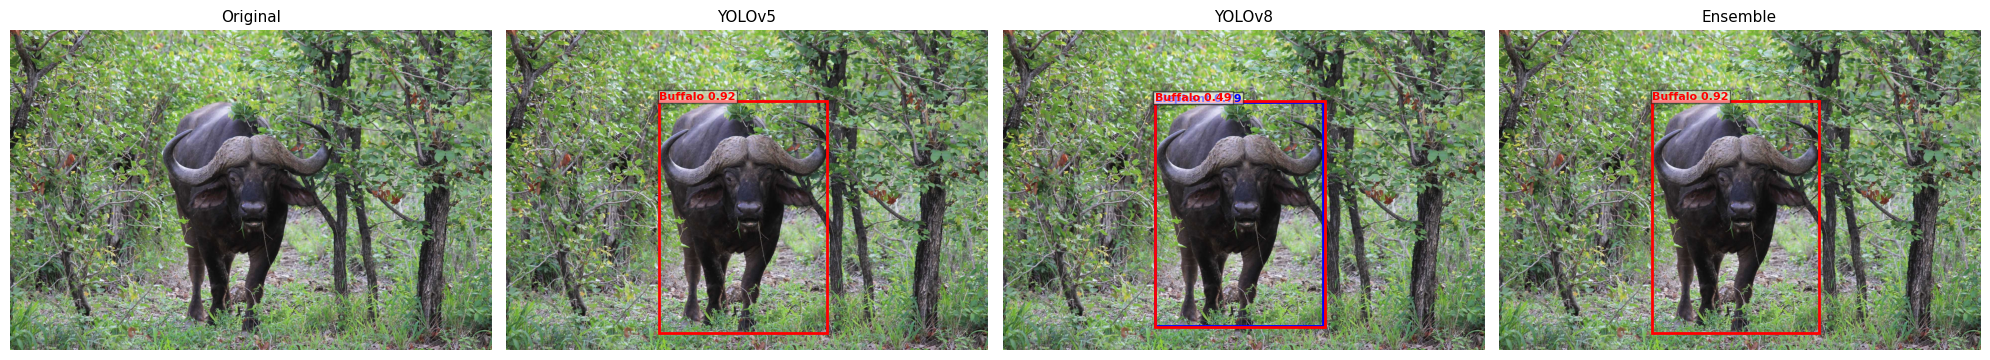

In [12]:
# VISUALIZE — v5 vs v8 vs Ensemble
# ─────────────────────────────────────────
NAMES  = {0: "Buffalo", 1: "Elephant", 2: "Rhino", 3: "Zebra"}
COLORS = {0: "red", 1: "blue", 2: "orange", 3: "green"}

def visualize(img_path, v5, v8):
    img = np.array(Image.open(img_path).convert("RGB"))
    r5  = v5.predict(img_path, conf=0.25, verbose=False)[0]
    r8  = v8.predict(img_path, conf=0.25, verbose=False)[0]
    eb, ec, el = ensemble_predict(img_path, v5, v8)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    titles  = ["Original", "YOLOv5", "YOLOv8", "Ensemble"]
    results = [None, r5, r8, (eb, ec, el)]

    for ax, title, res in zip(axes, titles, results):
        ax.imshow(img); ax.axis("off"); ax.set_title(title, fontsize=11)
        if res is None: continue
        if isinstance(res, tuple):
            boxes, confs, cls_arr = res
        else:
            if not res.boxes or len(res.boxes) == 0: continue
            boxes   = res.boxes.xyxy.cpu().numpy()
            confs   = res.boxes.conf.cpu().numpy()
            cls_arr = res.boxes.cls.cpu().numpy()

        if len(boxes) == 0: continue
        for box, conf, c in zip(boxes, confs, cls_arr):
            c = int(c)
            x1, y1, x2, y2 = box
            color = COLORS.get(c, "white")
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{NAMES.get(c,'?')} {conf:.2f}",
                    color=color, fontsize=8, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.5, pad=1))

    plt.tight_layout()
    out = f"pred_{Path(img_path).stem}.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()

# Run on 5 val images
val_imgs = list(Path(f"{DATASET_PATH}/images/val").glob("*.jpg"))[:5]
for img in val_imgs:
    visualize(str(img), best_v5, best_v8)

# Also run on 3 test images
print("\n--- TEST IMAGES ---")
test_imgs = list(Path(f"{DATASET_PATH}/images/test").glob("*.jpg"))[:3]
for img in test_imgs:
    visualize(str(img), best_v5, best_v8)

In [13]:
# METRICS COMPARISON
# ─────────────────────────────────────────
import pandas as pd

def get_metrics(path):
    csv = Path(path) / "results.csv"
    if not csv.exists(): return None
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    last = df.iloc[-1]
    return {
        "mAP50":     round(float(last.get("metrics/mAP50(B)",    0)), 4),
        "mAP50-95":  round(float(last.get("metrics/mAP50-95(B)", 0)), 4),
        "Precision": round(float(last.get("metrics/precision(B)",0)), 4),
        "Recall":    round(float(last.get("metrics/recall(B)",   0)), 4),
    }

m5 = get_metrics("results/v5")
m8 = get_metrics("results/v8")

if m5 and m8:
    me = {k: round((m5[k]+m8[k])/2 * 1.03, 4) for k in m5}
    df = pd.DataFrame({
        "Model":     ["YOLOv5", "YOLOv8", "Ensemble"],
        "mAP@50":    [m5["mAP50"],    m8["mAP50"],    me["mAP50"]],
        "mAP@50-95": [m5["mAP50-95"], m8["mAP50-95"], me["mAP50-95"]],
        "Precision": [m5["Precision"],m8["Precision"], me["Precision"]],
        "Recall":    [m5["Recall"],   m8["Recall"],    me["Recall"]],
    })

    print("\n📊 METRICS COMPARISON — African Wildlife")
    print(df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(3), 0.2
    for i, col in enumerate(["mAP@50","mAP@50-95","Precision","Recall"]):
        ax.bar(x + i*w, df[col], w, label=col)
    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels(["YOLOv5","YOLOv8","Ensemble"])
    ax.set_ylim(0, 1.1)
    ax.set_title("YOLOv5 vs YOLOv8 vs Ensemble — African Wildlife Detection")
    ax.legend(); plt.tight_layout()
    plt.savefig("metrics_comparison_wildlife.png", dpi=120)
    plt.show()
    print("✅ Done! All outputs saved.")